# Matplotlib 画图入门（二）：多子图、热力图与 seaborn

**目标**：多子图布局 + 热力图（生信里最常见的图之一）+ seaborn 一行出统计图。

**配套理论**：Matplotlib subplots 官方文档；seaborn 官方教程（https://seaborn.pydata.org/tutorial.html ）Intro 篇；Python Data Science Handbook 第 4 章 Visualization with Seaborn。

**要点**：seaborn 是对 matplotlib 的封装，底层还是 matplotlib 的 figure/axes

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("seaborn", sns.__version__)

seaborn 0.13.2


## 1. 多子图：fig, axes = plt.subplots(2, 2)

**要点**： subplots(nrows, ncols)  返回  (figure, axes数组) 。axes 是 numpy 数组，用  axes[行, 列]  定位子图；每张子图独立装饰（各自 set_title/set_xlabel）。

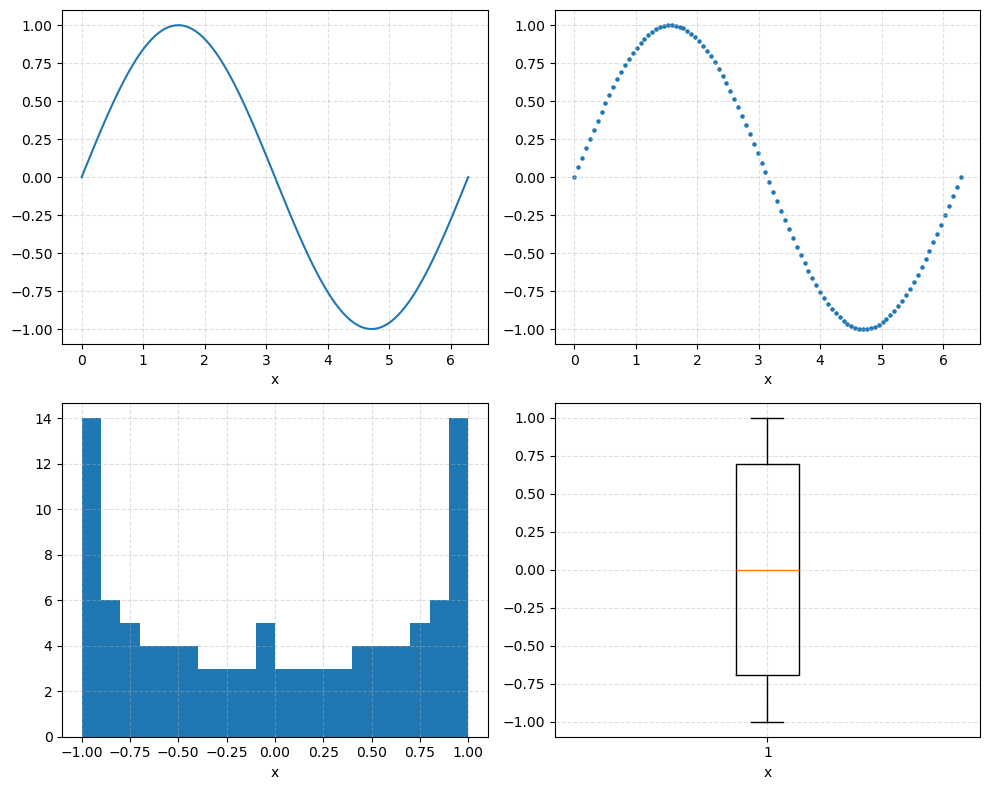

In [2]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].plot(x, y)                    # 左上
axes[0, 1].scatter(x, y, s=5)            # 右上
axes[1, 0].hist(y, bins=20)              # 左下
axes[1, 1].boxplot(y)                    # 右下

for ax in axes.ravel():                  # ravel() 把 2x2 拉平成 1 维，方便统一装饰
    ax.set_xlabel("x")
    ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()                       # 自动调间距，防止标签被裁
plt.show()

**要点**： axes.ravel()  把多维子图数组拉平成一维，配合循环可以批量设置样式，不用手写 4 遍。

### 1.1 共享坐标轴（对比图的规范）

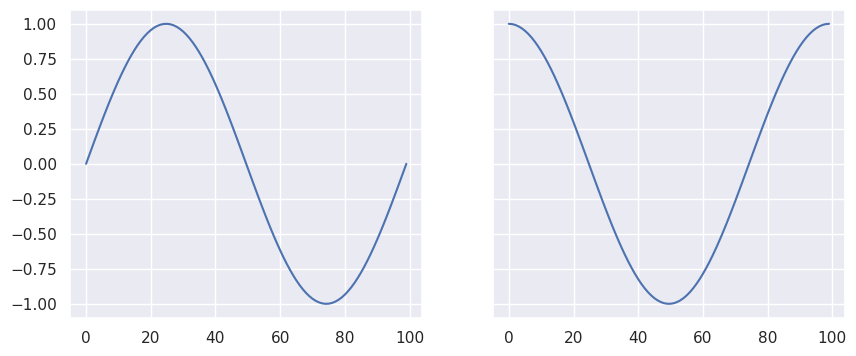

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].plot(np.sin(x), label="sin")
axes[1].plot(np.cos(x), label="cos")
plt.show()

# sharey=True：两个子图共用 y 轴刻度范围
# 不共享的后果：两图刻度范围不同，视觉上"看起来"波动幅度差异很大，误导读者

**要点**：**对比图必须共享轴**（sharex/sharey），否则不同刻度范围会让视觉比例失真——这是数据可视化最常见的误导错误之一

## 2. 热力图：imshow 手写版

**要点**：热力图输入必须是 2D 矩阵（行×列）；cmap 是颜色映射，把数值映射成颜色。

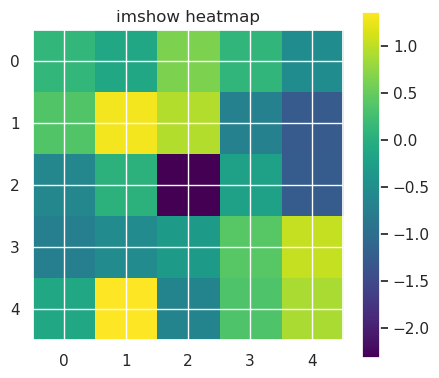

In [13]:
rng = np.random.default_rng(0)      # 随机种子为 0
matrix = rng.normal(0, 1, (5, 5))   # 5x5 随机矩阵

fig, ax = plt.subplots(figsize=(5, 4.5))  # 默认一块画板
im = ax.imshow(matrix, cmap="viridis")    # imshow()：热力图 / 矩阵热图，把二维矩阵渲染成彩色方格图; cmap="viridis" 是感知均匀色板，适合科研
ax.set_xticks(range(5))         # X 轴刻度位置设置为：0, 1, 2, 3, 4
ax.set_yticks(range(5))         # Y 轴刻度位置设置为：0, 1, 2, 3, 4
fig.colorbar(im, ax=ax)         # 右侧色条：标注数值→颜色的对应
ax.set_title("imshow heatmap")
plt.show()

**要点**：
-  colorbar  必须有——没有色条，读者不知道颜色代表多少数值；
-  cmap  选择有讲究： viridis/plasma 是感知均匀映射（色盲友好）；**彩虹图  `jet`  是禁区**——它在数值变化平缓处制造肉眼可见的"假边界"，专业图禁用；
- 生信场景（表达矩阵热图）几乎都用 cmap="Reds"  或  "viridis" 。
- 如果不加 colorbar，只能看见色块，不知道每种颜色代表多大数值

### 2.1 seaborn 一行出热力图（实际工作常用）

**要点**： sns.heatmap  直接吃  DataFrame.corr()  的结果；seaborn 画的仍是 matplotlib 的 ax，所以 ax= 参数能把图放进任意子图位置。

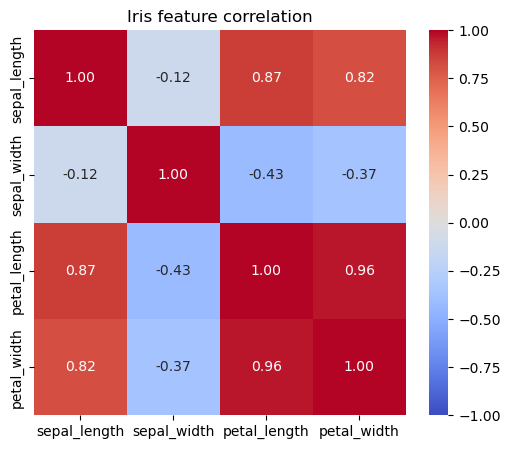

In [5]:
df = sns.load_dataset("iris")                       # 加载 seaborn 内置数据集
corr = df.select_dtypes("number").corr()             # 只取数值列，算相关矩阵

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, ax=ax)
ax.set_title("Iris feature correlation")
plt.show()

**要点**： 
- annot=True  在格子里写数值（配合 fmt=".2f" 控制小数位）； vmin/vmax  固定色标范围——不同数据、不同批次跑出来颜色才可比；热力图值域默认就是 [-1, 1]（相关系数），固定范围是规范。

corr = df.select_dtypes("number").corr()
- select_dtypes("number")：**筛出所有数值类型的列**，自动把字符串标签列 species 丢掉。
- 因为类别字符串不能计算皮尔逊相关系数。
- .corr()：计算**皮尔逊相关系数矩阵**
  - 输出二维方阵，行列都是特征名
  - 系数取值范围：[-1,1]
    - +1：完全正相关
    -  0：无线性相关
    - -1：完全负相关

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, ax=ax)
|参数|	含义|
| ---  |  ---  |
|corr	|输入二维相关系数矩阵|
|annot=True	|在每个色块内部打印出具体数值|
|cmap="coolwarm"	|冷暖色板：蓝色代表负相关，白色代表 0，红色代表正相关，相关分析的首选色板|
|fmt=".2f"	|打印数值格式：保留小数点后 2 位|
|vmin=-1	|颜色条最小值固定‑1（相关系数下限）|
|vmax=1|	颜色条最大值固定 + 1（相关系数上限）|
|ax=ax	|指定画到你创建好的 ax 画板，面向对象写法，避免 plt 全局陷阱|




## 3. seaborn 统计图速览（数据框友好）

**要点**：seaborn 的画图函数第一个参数是 data=DataFrame ，列名用字符串直接引用——不用手动拆列；hue= 按类别自动着色+图例，是 seaborn 最强大的参数（一个参数搞定分组可视化）。

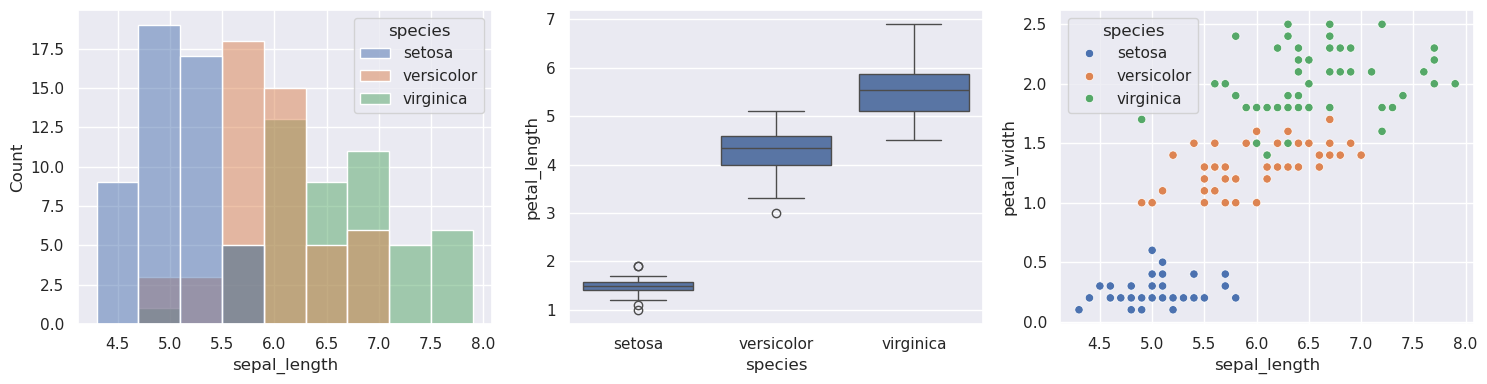

In [6]:
sns.set_theme()  # seaborn 默认样式（网格+配色），比 matplotlib 默认好看

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=df, x="sepal_length", hue="species", ax=axes[0])   # 分组直方图
sns.boxplot(data=df, x="species", y="petal_length", ax=axes[1])      # 分组箱线图
sns.scatterplot(data=df, x="sepal_length", y="petal_width", hue="species", ax=axes[2])
fig.tight_layout()
plt.show()

**要点**： hue="species"  让三个类别自动分开着色并生成图例——这在分组对比时是刚需；seaborn 图也可以放进   subplots  的子图里（通过 ax=），和 matplotlib 无缝混用。

## 4. 本节自测题

1.plt.subplots(2, 3) 返回什么？怎么访问第 2 行第 1 列的子图？ravel() 解决什么问题？
- 一个 fig 画布，一个 axes numpy数组; axes[1,0]; 把多维数组拉平成一维，就类似于 flatten() 函数

2.为什么对比图要 sharey=True？不共享会有什么误导？
- 不共享的话可能会不同刻度范围会让视觉比例失真;两组数据范围 0-10 和 0-100，不 sharey 时各自自动缩放，图上看起来"波动幅度差不多"，实际差 10 倍——对比结论直接被误导

3.为什么禁止用 jet 彩虹色做热力图？应该选什么替代？
- jet 彩虹色板亮度变化不均匀，不具备感知均匀性，容易在热力图上产生虚假边界，误导读者；同时色盲可读性差，灰度打印后梯度信息丢失

4.sns.heatmap 的 annot、fmt、vmin/vmax 各起什么作用？
- annotate，**是否在每一个色块格子内打印出对应数值**; `fmt`,**控制格子内文字的输出格式和精度**; vmin,vmax, 颜色标尺的**最小值、最大值**，用来锁定色条的数值范围,锁死后不同数据集/不同子图的颜色才可比，否则颜色深浅是相对的

5.seaborn 的 hue 参数解决了什么问题？它要求数据以什么形式组织？
- 让所有类别自动分开着色并生成图例——这在分组对比时是刚需;长格式（tidy data）：每行一个观测，分组类别是某一列里的值。如果数据是宽格式（每个类别占一列），hue 就没法用